In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def wrap_angle(a):
    return np.arctan2(np.sin(a), np.cos(a))

In [3]:
df_raw_vx = pd.read_csv('../../../../../Data/Animal_Trajectory_Data/crabs/crab_105N_vx.csv')
df_raw_vy = pd.read_csv('../../../../../Data/Animal_Trajectory_Data/crabs/crab_105N_vy.csv')
wind_direction = np.pi

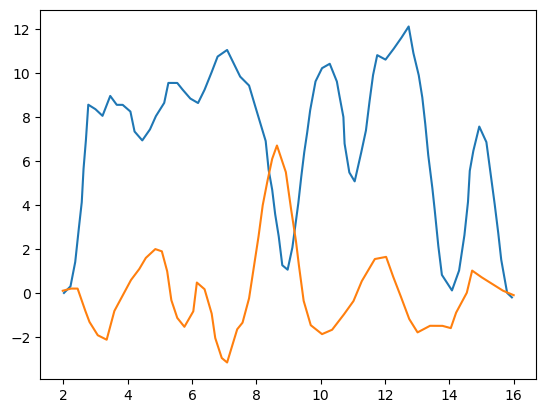

In [4]:
plt.plot(df_raw_vx.time.values, df_raw_vx.xvel.values)
plt.plot(df_raw_vy.time.values, df_raw_vy.yvel.values)

In [5]:
# drop backwards times

ix_vx_drop = np.where(np.diff(df_raw_vx.time.values)<0)[0]
df_raw_vx = df_raw_vx.drop(ix_vx_drop)

ix_vy_drop = np.where(np.diff(df_raw_vy.time.values)<0)[0]
df_raw_vy = df_raw_vy.drop(ix_vy_drop)

In [6]:
from scipy.interpolate import UnivariateSpline

In [7]:
interp_timestamps_sec = np.arange(df_raw_vx.time.min(), df_raw_vx.time.max(), 0.1)

In [8]:
spline_x = UnivariateSpline(df_raw_vx.time, df_raw_vx.xvel, s=2, k=3)  # s=smoothing amount
interp_vx = spline_x(interp_timestamps_sec)

spline_y = UnivariateSpline(df_raw_vy.time, df_raw_vy.yvel, s=2, k=3)  # s=smoothing amount
interp_vy = spline_y(interp_timestamps_sec)

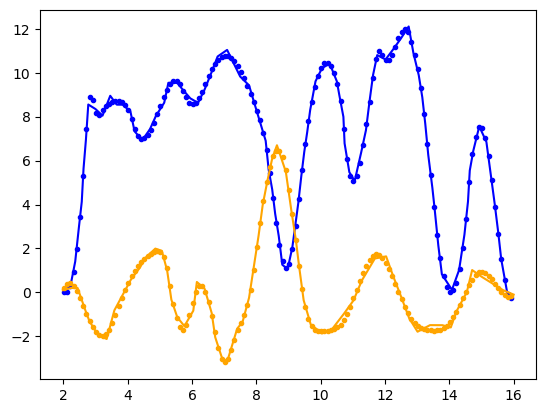

In [9]:
plt.plot(df_raw_vx.time.values, df_raw_vx.xvel.values, color='blue')
plt.plot(interp_timestamps_sec, interp_vx, '.', color='blue')


plt.plot(df_raw_vy.time.values, df_raw_vy.yvel.values, color='orange')
plt.plot(interp_timestamps_sec, interp_vy, '.', color='orange')

In [10]:
dt = np.median(np.diff(interp_timestamps_sec))
x = np.cumsum(interp_vx*dt)
y = np.cumsum(interp_vy*dt)

In [11]:
df_calibrated_interp = pd.DataFrame({'timestamps_sec': interp_timestamps_sec,
                                     'x': x,
                                     'y': y,
                                     'xvel': interp_vx,
                                     'yvel': interp_vy})

4.018445322800002


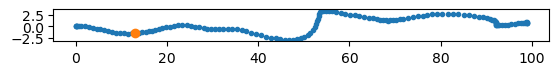

In [12]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(df_calibrated_interp.x.values, df_calibrated_interp.y.values, '.')

tix = 20
ax.plot(df_calibrated_interp.x.values[tix], df_calibrated_interp.y.values[tix], 'o')

print(df_calibrated_interp.timestamps_sec.values[tix])

ax.set_aspect('equal')

In [13]:
import pynumdiff

In [14]:
dt = np.median(np.diff(df_calibrated_interp.timestamps_sec.values))
_, xvel = pynumdiff.savgoldiff(df_calibrated_interp.x, dt, [2, 3, 3])
_, yvel = pynumdiff.savgoldiff(df_calibrated_interp.y, dt, [2, 3, 3])

In [15]:
from braid_analysis import flymath

df_calibrated_interp['xvel'] = xvel
df_calibrated_interp['yvel'] = yvel
df_calibrated_interp['time_relative_to_flash'] = df_calibrated_interp['timestamps_sec'] - df_calibrated_interp.timestamps_sec.values[tix]
df_calibrated_interp['obj_id_unique_event'] = 'shark_a'
df_calibrated_interp['obj_id_unique'] = 'shark_a'
df_calibrated_interp = flymath.assign_course_and_ang_vel_to_dataframe(df_calibrated_interp)

df_calibrated_interp.course_smoothish -= wind_direction + np.pi
df_calibrated_interp.course_smoothish = wrap_angle(df_calibrated_interp.course_smoothish)

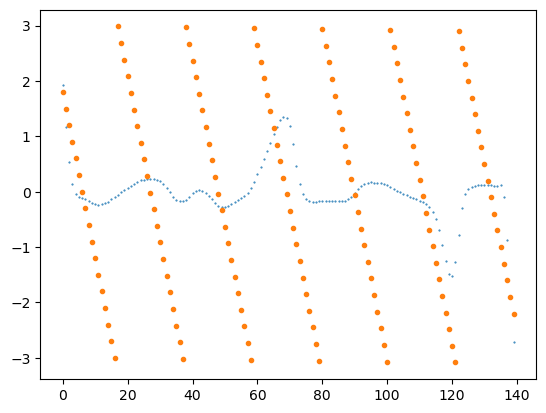

In [16]:
plt.plot(df_calibrated_interp.course_smoothish, '.', markersize=1)

ix = df_calibrated_interp.index.values
slope = -0.3
intercept=1.8
line = slope*ix + intercept

plt.plot(ix, wrap_angle(line), '.')


In [17]:
from align_course_direction_analysis import unifying_algo_analysis as uaa

In [18]:
trajec = df_calibrated_interp

In [19]:
trajec.shape

(140, 11)

In [20]:
course = trajec.course_smoothish.values
abs_min_ix = 20 # 1 second after the flash start; roughly 300 ms after flash end. Adjust based on your data.
abs_max_ix = 69 # 5 seconds after the flash start. 
min_ix_range = 37 # Use a ~2 sec window for fit
max_ix_range = 45 # Use a ~2 sec window for fit

In [21]:
unifying_algo_fit = uaa.bootstrap_miop_affine_fit(course, 
                                                  abs_min_ix, abs_max_ix, min_ix_range, max_ix_range, 
                                                  npoints = 30, 
                                                  n_bootstraps=2, 
                                                  use_cvx_affine=True, 
                                                  include_translation=True, 
                                                  pis_max = 20, 
                                                  intercept_max = 4,
                                                  huber_M=1.0,
                                                  ignore_large_errors=True,
                                                  error_threshold=2.0,
                                                  large_error_penalty=1.0)

Restricted license - for non-production use only - expires 2027-11-29


In [22]:
# Sort 
sorted_fit = unifying_algo_fit.sort_values('rmse_affine')
best_ix = sorted_fit.index[0]
best_unifying_algo_fit = unifying_algo_fit.iloc[best_ix]

In [23]:
sorted_fit

,min_ix,max_ix,abs_min_ix,abs_max_ix,min_ix_range,max_ix_range,slope,intercept,rotation,major_axis,...,tx,ty,rho,mean_residuals,axis_ratio,rmse_affine,shift_ix,iteration,obj_id_unique_event,timestep_sec
0,20,61,20,69,37,45,-0.003534,-6.107484,1.579948,2.001251,...,1.564790,-0.052724,0.501148,-0.000393,0.289464,0.146396,50,0,None,None
1,25,63,20,69,37,45,-0.001342,0.061330,-3.134246,159.511219,...,-158.509137,-1.169021,0.060277,0.002457,0.008569,0.205974,46,1,None,None


In [24]:
ix_all, course, linear_fit_angle, affine_fit_angle = uaa.build_miop_and_affine_predictions_from_model(course, best_unifying_algo_fit)

ValueError: too many values to unpack (expected 4)

In [101]:
import figurefirst as fifi

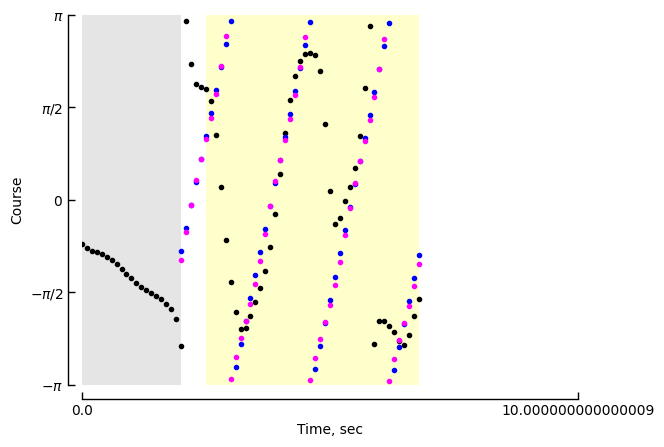

In [103]:
fig = plt.figure()
ax = fig.add_subplot(111)

# shading for before search
ax.fill_betweenx([np.pi, -np.pi], 
                 0, 
                 abs_min_ix, 
                 color='gray', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# add shading for region of interest where fit was applied
min_ix = int(best_unifying_algo_fit.min_ix)
max_ix = int(best_unifying_algo_fit.max_ix)
ax.fill_betweenx([np.pi, -np.pi], 
                 min_ix, 
                 max_ix, 
                 color='yellow', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# plot course, linear fit, and affine fit
ax.plot(ix_all, course, '.', color='black')
ax.plot(ix_all[abs_min_ix:], linear_fit_angle[abs_min_ix:], '.', color='blue')
ax.plot(ix_all[abs_min_ix:], affine_fit_angle[abs_min_ix:], '.', color='magenta')

# Add ticks, labels, etc. 
ax.set_xlim(0, ix_all[-1])
ax.set_ylim(-np.pi, np.pi)

xticks = np.arange( np.min(ix_all), np.max(ix_all) + 50, 100)
dt = np.median(np.diff(df_calibrated_interp.timestamps_sec.values))
xticklabels = dt*xticks
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_xlabel('Time, sec')

ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['$-\pi$', '$-\pi/2$','$0$','$\pi/2$','$\pi$',])
ax.set_ylabel('Course')

fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'])